In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# loading and inspection

In [6]:

csv_path = next(Path("../data").rglob("*.csv"))
df = pd.read_csv(csv_path)
print(csv_path.name)

sri_lanka_flood_risk_modeled.csv


In [7]:
print(df.shape)

(91325, 19)


In [8]:
print(df.head())

         date  precipitation_sum  rain_sum  soil_moisture_0_to_7cm_mean  \
0  2015-01-01                1.6       1.6                        0.375   
1  2015-01-02                1.3       1.3                        0.372   
2  2015-01-03                0.0       0.0                        0.361   
3  2015-01-04                0.2       0.2                        0.349   
4  2015-01-05                3.3       3.3                        0.349   

   soil_moisture_7_to_28cm_mean  temperature_2m_max  wind_speed_10m_max  \
0                         0.378                29.1                 8.2   
1                         0.373                28.9                 7.9   
2                         0.368                29.4                11.4   
3                         0.360                29.1                13.9   
4                         0.353                27.8                16.5   

  district  latitude  longitude province climatic_zone  rain_24h  rain_48h  \
0   Ampara    7.2912

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 91325 entries, 0 to 91324
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          91325 non-null  str    
 1   precipitation_sum             91325 non-null  float64
 2   rain_sum                      91325 non-null  float64
 3   soil_moisture_0_to_7cm_mean   91325 non-null  float64
 4   soil_moisture_7_to_28cm_mean  91325 non-null  float64
 5   temperature_2m_max            91325 non-null  float64
 6   wind_speed_10m_max            91325 non-null  float64
 7   district                      91325 non-null  str    
 8   latitude                      91325 non-null  float64
 9   longitude                     91325 non-null  float64
 10  province                      91325 non-null  str    
 11  climatic_zone                 91325 non-null  str    
 12  rain_24h                      91325 non-null  float64
 13  rain_48h    

# data quality checks

In [10]:
print(df.isna().sum().sum(), "missing values")
print(df.duplicated().sum(), "duplicate rows")
df.describe().T

0 missing values
0 duplicate rows


,count,mean,std,min,25%,50%,75%,max
precipitation_sum,91325.0,5.546671,10.224598,0.0000,0.2000,1.8000,6.7000,321.8000
rain_sum,91325.0,5.546671,10.224598,0.0000,0.2000,1.8000,6.7000,321.8000
soil_moisture_0_to_7cm_mean,91325.0,0.332286,0.126538,0.0110,0.2330,0.3500,0.4430,0.5180
soil_moisture_7_to_28cm_mean,91325.0,0.327313,0.120991,0.0170,0.2230,0.3340,0.4300,0.5180
temperature_2m_max,91325.0,29.900777,3.253310,14.7000,28.4000,29.8000,31.7000,40.4000
wind_speed_10m_max,91325.0,17.156757,6.948491,2.5000,12.1000,16.2000,21.0000,76.0000
latitude,91325.0,7.588212,1.033023,5.9549,6.9271,7.2912,8.3114,9.6615
longitude,91325.0,80.587948,0.533065,79.8394,80.2210,80.4982,81.0188,81.6747
rain_24h,91325.0,5.546671,10.224598,0.0000,0.2000,1.8000,6.7000,321.8000
rain_48h,91325.0,11.089380,17.677075,0.0000,0.9000,4.6000,14.6000,481.5000


In [11]:
# adjust "date" if the column is named differently
df["date"] = pd.to_datetime(df["date"])
print(df["date"].min(), df["date"].max())
print(df["district"].nunique(), "districts")
print(df.groupby("district").size().describe())

print(df["flood_category"].value_counts())
print(df["flood_category"].value_counts(normalize=True).round(4))

2015-01-01 00:00:00 2024-12-31 00:00:00
25 districts
count      25.0
mean     3653.0
std         0.0
min      3653.0
25%      3653.0
50%      3653.0
75%      3653.0
max      3653.0
dtype: float64
flood_category
Low Risk (Normal)                             84693
Advisory (Waterlogging)                        6458
High Warning (Inundation)                       128
Critical Emergency (Catastrophic Overflow)       46
Name: count, dtype: int64
flood_category
Low Risk (Normal)                             0.9274
Advisory (Waterlogging)                       0.0707
High Warning (Inundation)                     0.0014
Critical Emergency (Catastrophic Overflow)    0.0005
Name: proportion, dtype: float64


### leakage check

flood_risk_score         1.000000
precipitation_sum        0.830680
rain_24h                 0.830680
rain_48h                 0.783286
rain_72h                 0.736646
soil_saturation_index    0.386774
Name: flood_risk_score, dtype: float64


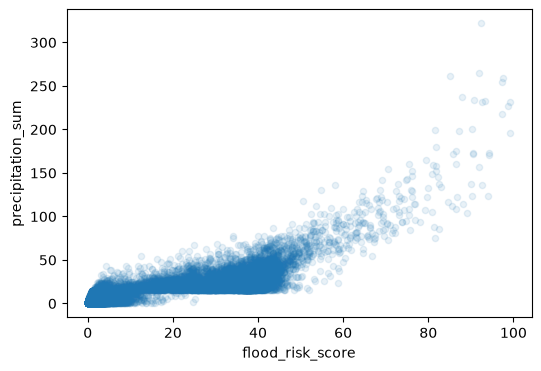

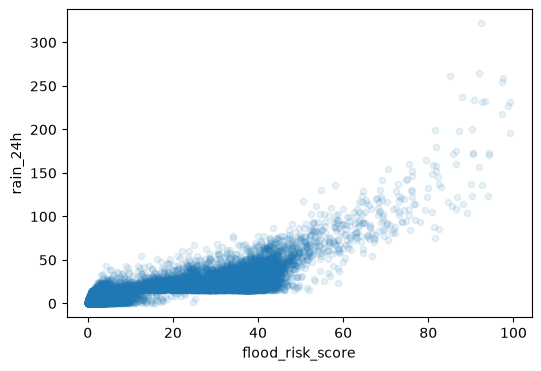

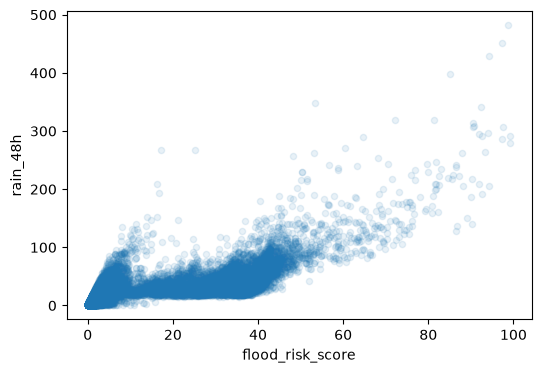

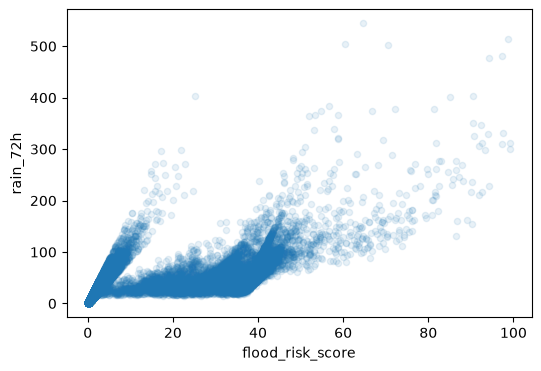

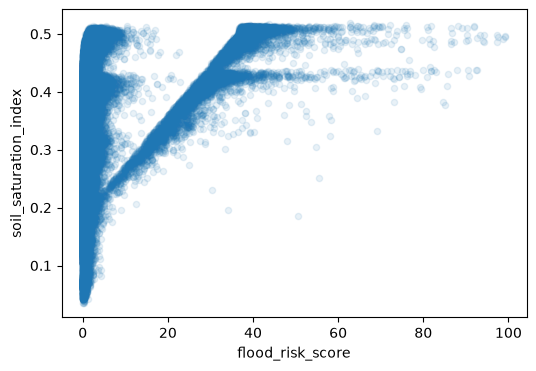

In [18]:
cols = ["precipitation_sum", "rain_24h", "rain_48h", "rain_72h",
        "soil_saturation_index", "flood_risk_score"]
print(df[cols].corr()["flood_risk_score"].sort_values(ascending=False))

for col in cols:
    if col != "flood_risk_score":
        df.plot.scatter(x="flood_risk_score", y=col, alpha=0.1, figsize=(6, 4))
        plt.show()

seasonality and zones

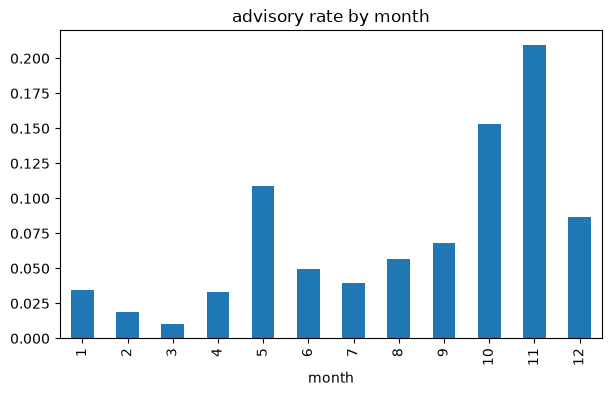

climatic_zone
Dry             0.027352
Intermediate    0.080756
Wet             0.129361
Name: is_advisory, dtype: float64
year
2015    0.083616
2016    0.034754
2017    0.066959
2018    0.082411
2019    0.074630
2020    0.054208
2021    0.088548
2022    0.067945
2023    0.100055
2024    0.073224
Name: is_advisory, dtype: float64


In [23]:
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

df["is_advisory"] = df["flood_category"].ne("Low Risk (Normal)").astype(int)
df.groupby("month")['is_advisory'].mean().plot(kind="bar", figsize=(7,4))
plt.title("advisory rate by month")
plt.show()

print(df.groupby("climatic_zone")["is_advisory"].mean())
print(df.groupby("year")["is_advisory"].mean())

check the Cyclone Roanu event (May 2016) 

In [24]:
roanu = df[(df["date"] >= "2016-05-14") & (df["date"] <= "2016-05-18")]
roanu.sort_values("flood_risk_score", ascending=False)[
    ["date", "district", "rain_72h", "flood_risk_score", "flood_category"]
].head(10)

,date,district,rain_72h,flood_risk_score,flood_category
22418,2016-05-15,Gampaha,311.4,99.3,Critical Emergency (Catastrophic Overflow)
33377,2016-05-15,Kalutara,300.3,99.3,Critical Emergency (Catastrophic Overflow)
47990,2016-05-16,Kurunegala,514.4,98.7,Critical Emergency (Catastrophic Overflow)
40683,2016-05-15,Kegalle,330.6,97.6,Critical Emergency (Catastrophic Overflow)
47989,2016-05-15,Kurunegala,309.0,97.4,Critical Emergency (Catastrophic Overflow)
55296,2016-05-16,Matale,481.3,97.2,Critical Emergency (Catastrophic Overflow)
40684,2016-05-16,Kegalle,477.3,94.3,Critical Emergency (Catastrophic Overflow)
37030,2016-05-15,Kandy,227.6,94.2,Critical Emergency (Catastrophic Overflow)
37031,2016-05-16,Kandy,330.1,94.0,Critical Emergency (Catastrophic Overflow)
55295,2016-05-15,Matale,298.2,93.3,Critical Emergency (Catastrophic Overflow)


### build the 48-hour-ahead target (preview only)

In [26]:
df = df.sort_values(["district", "date"]).reset_index(drop=True)
df["advisory_48h"] = df.groupby("district")["is_advisory"].shift(-2)
df = df.dropna(subset=["advisory_48h"])
print(df["advisory_48h"].value_counts(normalize=True))

advisory_48h
0.0    0.92734
1.0    0.07266
Name: proportion, dtype: float64


In [27]:
print((df["precipitation_sum"] == df["rain_sum"]).all(),
      (df["precipitation_sum"] == df["rain_24h"]).all())

True True


# conclusions

#### the data is clean, no missing values or duplicates and exactly 3653 days for each of the 25 districts 
#### three columns precipitation_sum, rain_sum and rain_24h have identical statistics at every quantile. we can keep one and drop the other two 
#### The rolling windows are trailing sums (rain_48h on day 2 is day 1 plus day 2), so they contain no future information.
#### The classes are heavily imbalanced. Low Risk is 92.7% and Advisory 7.1%, but High Warning (128 rows) and Critical Emergency (46 rows) are far too rare to model as separate classes. The right task is binary: advisory or higher vs Low Risk. Our 48-hour target has a 7.27% positive rate, which is moderate imbalance, so use PR-AUC, recall and F1
#### Every year has enough positives. Rates range from 3.5% (2016) to 10.0% (2023), so a time-based split works.
#### Seasonality and zone matter. Advisory rates peak in October and November (about 15% and 21%), with a secondary peak in May (about 11%). They are lowest in February and March. By zone, Wet is 12.9%, Intermediate 8.1% and Dry 2.7%. Month and zone are worth including as features.
#### The Roanu check worked. Gampaha and Kalutara reach 99.3, and Kurunegala shows 514.4 mm of 72-hour rain with a score of 98.7. That matches the dataset description, so your date handling is right.
#### The correlations (0.83 for same-day rain, 0.39 for soil saturation) and the fuzzy scatter show the score isn't a simple linear function of rain, because it uses district-specific thresholds. A tree model given district plus same-day rain and soil could still reproduce it almost exactly, so predicting ahead is still the right framing.
